## NEIMETH STOCK PRICE PREDICTION

In [1]:
## to change the name across the code
## ctrl + h will open the tab the fill the new name in replace
## to change the name across the entire code so you dont have to click enter everytime
## ctrl + shift + h

import pandas as pd

neimeth=pd.read_csv('../stock_data/neimeth.csv') ## so it can be small letter. This is cool.
neimeth=neimeth.drop(columns=['high_price','low_price'])
neimeth.rename(columns={'trade_date':'date'},inplace=True)
neimeth['date']=pd.to_datetime(neimeth['date'])
neimeth['month']=neimeth['date'].dt.month
neimeth['quarter']=neimeth['date'].dt.quarter
neimeth['year']=neimeth['date'].dt.year

neimeth

,id,symbol,date,open_price,close_price,volume,created_at,month,quarter,year
0,42834,NEIMETH,2017-01-03,0.78,0.78,41100,2026-04-08T02:41:25.765521+00:00,1,1,2017
1,43394,NEIMETH,2017-01-04,0.78,0.78,0,2026-04-08T02:42:20.164398+00:00,1,1,2017
2,43504,NEIMETH,2017-01-05,0.78,0.78,23480,2026-04-08T02:42:22.380516+00:00,1,1,2017
3,43614,NEIMETH,2017-01-06,0.78,0.78,35160,2026-04-08T02:42:23.84796+00:00,1,1,2017
4,43704,NEIMETH,2017-01-09,0.78,0.78,5169,2026-04-08T02:42:26.938159+00:00,1,1,2017
...,...,...,...,...,...,...,...,...,...,...
2258,298104,NEIMETH,2026-07-13,8.95,8.95,1738435,2026-07-13T15:10:02.995074+00:00,7,3,2026
2259,298542,NEIMETH,2026-07-14,9.05,9.05,1971880,2026-07-14T15:10:03.094441+00:00,7,3,2026
2260,298980,NEIMETH,2026-07-15,9.05,9.05,918462,2026-07-15T15:10:03.078609+00:00,7,3,2026
2261,299418,NEIMETH,2026-07-16,9.05,9.05,501310,2026-07-16T15:10:03.113936+00:00,7,3,2026


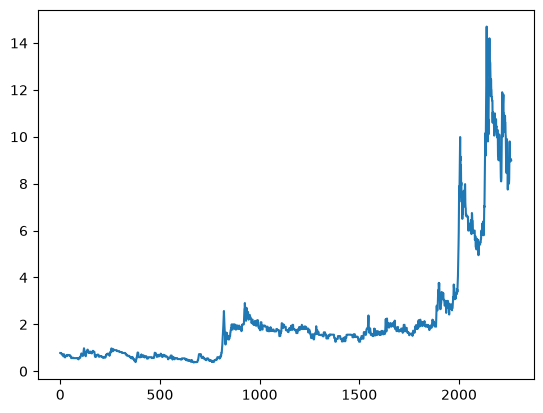

In [2]:
import matplotlib.pyplot as plt

plt.plot(neimeth['close_price'])
plt.show()

In [3]:
neimeth_end_month_df = (
    neimeth
    .sort_values("date")
    .groupby(neimeth["date"].dt.to_period("M"))
    .tail(1)
    .reset_index(drop=True)
)

neimeth_end_month_df

,id,symbol,date,open_price,close_price,volume,created_at,month,quarter,year
0,45404,NEIMETH,2017-01-31,0.65,0.65,1090000,2026-04-08T02:43:03.07753+00:00,1,1,2017
1,47226,NEIMETH,2017-02-28,0.69,0.69,30534,2026-04-08T02:44:45.006295+00:00,2,1,2017
2,49342,NEIMETH,2017-03-31,0.58,0.58,0,2026-04-08T02:45:42.281198+00:00,3,1,2017
3,51169,NEIMETH,2017-04-28,0.56,0.56,11800,2026-04-08T02:51:55.619599+00:00,4,2,2017
4,53092,NEIMETH,2017-05-31,0.63,0.63,138042,2026-04-08T02:52:57.421655+00:00,5,2,2017
...,...,...,...,...,...,...,...,...,...,...
110,35341,NEIMETH,2026-03-31,10.10,10.10,943463,2026-03-31T15:00:02.085058+00:00,3,1,2026
111,281167,NEIMETH,2026-04-30,8.30,8.30,2780931,2026-04-30T15:00:02.170664+00:00,4,2,2026
112,284233,NEIMETH,2026-05-29,10.20,10.20,974306,2026-05-29T15:00:02.455558+00:00,5,2,2026
113,294161,NEIMETH,2026-06-30,9.00,9.00,71551677,2026-06-30T15:10:03.08168+00:00,6,2,2026


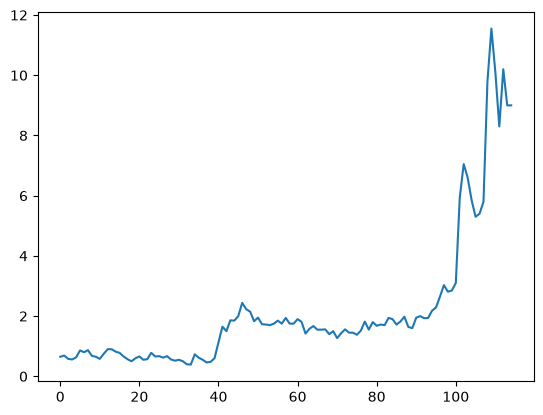

In [4]:
plt.plot(neimeth_end_month_df['close_price'])
plt.show()

In [5]:
neimeth_end_month_df['returns']=neimeth_end_month_df['close_price'].pct_change()*100
neimeth_end_month_df

,id,symbol,date,open_price,close_price,volume,created_at,month,quarter,year,returns
0,45404,NEIMETH,2017-01-31,0.65,0.65,1090000,2026-04-08T02:43:03.07753+00:00,1,1,2017,NaN
1,47226,NEIMETH,2017-02-28,0.69,0.69,30534,2026-04-08T02:44:45.006295+00:00,2,1,2017,6.153846
2,49342,NEIMETH,2017-03-31,0.58,0.58,0,2026-04-08T02:45:42.281198+00:00,3,1,2017,-15.942029
3,51169,NEIMETH,2017-04-28,0.56,0.56,11800,2026-04-08T02:51:55.619599+00:00,4,2,2017,-3.448276
4,53092,NEIMETH,2017-05-31,0.63,0.63,138042,2026-04-08T02:52:57.421655+00:00,5,2,2017,12.500000
...,...,...,...,...,...,...,...,...,...,...,...
110,35341,NEIMETH,2026-03-31,10.10,10.10,943463,2026-03-31T15:00:02.085058+00:00,3,1,2026,-12.554113
111,281167,NEIMETH,2026-04-30,8.30,8.30,2780931,2026-04-30T15:00:02.170664+00:00,4,2,2026,-17.821782
112,284233,NEIMETH,2026-05-29,10.20,10.20,974306,2026-05-29T15:00:02.455558+00:00,5,2,2026,22.891566
113,294161,NEIMETH,2026-06-30,9.00,9.00,71551677,2026-06-30T15:10:03.08168+00:00,6,2,2026,-11.764706


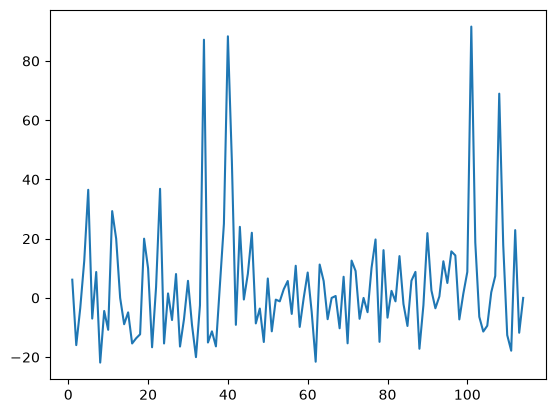

In [6]:
plt.plot(neimeth_end_month_df['returns'])
plt.show()

In [7]:
## Test stationarity

from statsmodels.tsa.stattools import adfuller

result = adfuller(neimeth_end_month_df['returns'].dropna())
print(result)
pvalue = result[1]
if pvalue < 0.05:
    print('stationary')
else:
    print('not stationary')

(np.float64(-2.7585706525902713), np.float64(0.06443967139096107), 6, 107, {'1%': np.float64(-3.492995948509562), '5%': np.float64(-2.888954648057252), '10%': np.float64(-2.58139291903223)}, np.float64(891.630957844174))
not stationary


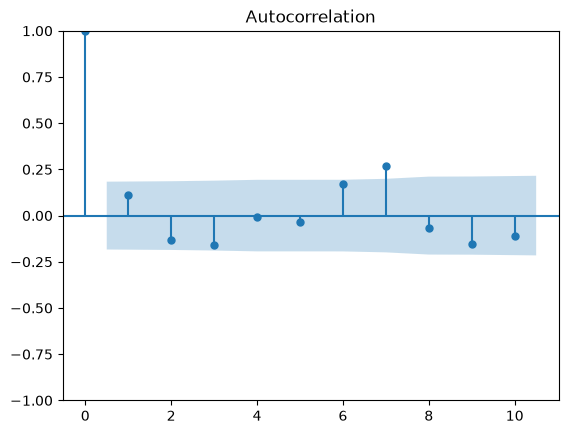

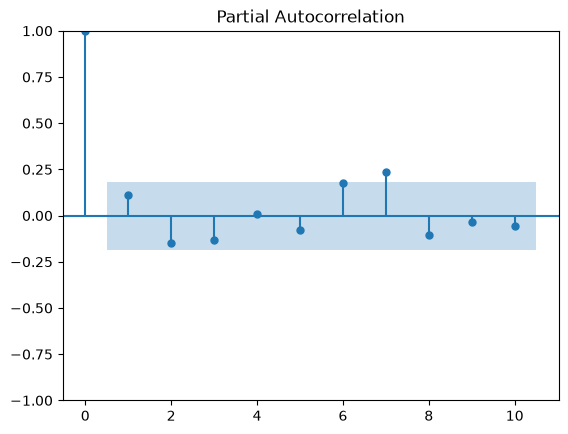

In [8]:
# Plotting the autocorrelation function and the partial autocorrelation function
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
plot_acf(neimeth_end_month_df['returns'].dropna(), lags=10)
plot_pacf(neimeth_end_month_df['returns'].dropna(), lags=10)
plt.show()

In [9]:
import random
random.seed(12345)

from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import matplotlib.pyplot as plt
import numpy as np
import warnings

warnings.filterwarnings('ignore')

train=neimeth_end_month_df['close_price'][:-10]
test=neimeth_end_month_df['close_price'][-10:]

# Grid Search on the SARIMA model
import numpy as np
scores = []
for p in range(3):
    for i in range(3):
        for q in range(3):
            for P in range(3):
                for D in range(3):
                    for Q in range(3):
                        try:
                            mod = SARIMAX(train, 
                            order=(p,i,q), seasonal_order=(P,D,Q,12))
                            res = mod.fit(disp=False)
                            fcst=res.forecast(steps=10)
                            score =  [p,i,q,P,D,Q,r2_score(test,fcst)]
                            print(score)
                            scores.append(score)
                            del mod
                            del res
                        except:
                            print('errored')


[0, 0, 0, 0, 0, 0, -16.174730253049002]
[0, 0, 0, 0, 0, 1, -8.911911379556534]
[0, 0, 0, 0, 0, 2, -8.002112292059369]
[0, 0, 0, 0, 1, 0, -5.89721436306834]
[0, 0, 0, 0, 1, 1, -5.881623169517638]
[0, 0, 0, 0, 1, 2, -5.9264838610099035]
[0, 0, 0, 0, 2, 0, -4.087828359862819]
[0, 0, 0, 0, 2, 1, -4.787832779027878]
[0, 0, 0, 0, 2, 2, -4.679300492923119]
[0, 0, 0, 1, 0, 0, -6.61889705724416]
[0, 0, 0, 1, 0, 1, -7.0205637055103]
[0, 0, 0, 1, 0, 2, -5.4088181872639245]
[0, 0, 0, 1, 1, 0, -5.886175680334228]
[0, 0, 0, 1, 1, 1, -5.585228045598873]
[0, 0, 0, 1, 1, 2, -5.720790250419681]
[0, 0, 0, 1, 2, 0, -4.211072622428714]
[0, 0, 0, 1, 2, 1, -4.714442778922483]
[0, 0, 0, 1, 2, 2, -4.422100563813678]
[0, 0, 0, 2, 0, 0, -6.825461357059279]
[0, 0, 0, 2, 0, 1, -6.387643600633195]
[0, 0, 0, 2, 0, 2, -6.862380930608797]
[0, 0, 0, 2, 1, 0, -6.007732145124042]
[0, 0, 0, 2, 1, 1, -5.685986071547606]
[0, 0, 0, 2, 1, 2, -5.531712389741681]
[0, 0, 0, 2, 2, 0, -4.63754541580539]
[0, 0, 0, 2, 2, 1, -4.89731

In [10]:
res = pd.DataFrame(scores)
res.columns = ['p', 'i', 'q', 'P', 'D', 'Q', 'score']
result = res.sort_values('score')
result

,p,i,q,P,D,Q,score
0,0,0,0,0,0,0,-16.174730
27,0,0,1,0,0,0,-15.791461
54,0,0,2,0,0,0,-15.147371
162,0,2,0,0,0,0,-12.562361
163,0,2,0,0,0,1,-12.260197
...,...,...,...,...,...,...,...
689,2,2,1,1,1,2,0.189044
698,2,2,1,2,1,2,0.189206
680,2,2,1,0,1,2,0.230526
688,2,2,1,1,1,1,0.230576


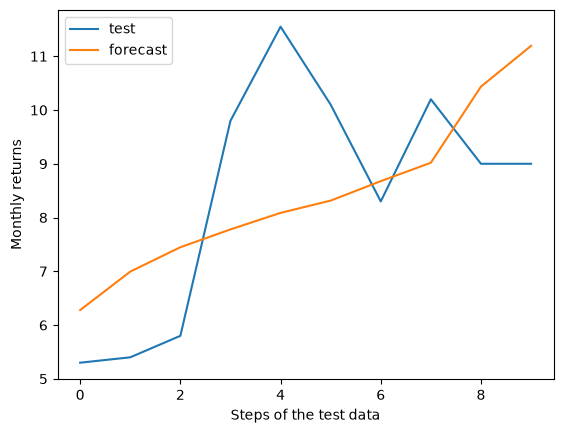

r2_score:  0.23143621169227013
rmse:  1.840861393343114
description:  count    115.000000
mean       2.152957
std        2.331711
min        0.390000
25%        0.685000
50%        1.600000
75%        1.945000
max       11.550000
Name: close_price, dtype: float64


In [11]:
# Fitting a SARIMAX model with our best model 
# order=(2,0,1), seasonal_order=(1,2,1,10)

import random
random.seed(12345)
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import numpy as np
import warnings

warnings.filterwarnings('ignore')

y_train=neimeth_end_month_df['close_price'][:-10]
y_test=neimeth_end_month_df['close_price'][-10:]

# scaler=StandardScaler()
# exog_train_scaled=scaler.fit_transform(X_full[:-10])
# exog_test_scaled=scaler.transform(X_full[-10:])

mod = SARIMAX(
y_train,
order=(2,2,1), 
seasonal_order=(0,1,1,12),
)

res = mod.fit(disp=False)
fcst = res.forecast(steps=10)

plt.plot(list(y_test))
plt.plot(list(fcst))
plt.xlabel('Steps of the test data')
plt.ylabel('Monthly returns')
plt.legend(['test', 'forecast'])
plt.show()
print('r2_score: ',r2_score(y_test, fcst))
print('rmse: ', np.sqrt(mean_squared_error(y_test,fcst)))
print('description: ', neimeth_end_month_df.close_price.describe())

Its not capturing the variations properly. Lets try the returns

In [12]:
import random
random.seed(12345)

from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import matplotlib.pyplot as plt
import numpy as np
import warnings

warnings.filterwarnings('ignore')

train=neimeth_end_month_df['returns'].dropna()[:-10]
test=neimeth_end_month_df['returns'].dropna()[-10:]

# Grid Search on the SARIMA model
import numpy as np
scores = []
for p in range(3):
    for i in range(3):
        for q in range(3):
            for P in range(3):
                for D in range(3):
                    for Q in range(3):
                        try:
                            mod = SARIMAX(train, 
                            order=(p,i,q), seasonal_order=(P,D,Q,12))
                            res = mod.fit(disp=False)
                            fcst=res.forecast(steps=10)
                            score =  [p,i,q,P,D,Q,r2_score(test,fcst)]
                            print(score)
                            scores.append(score)
                            del mod
                            del res
                        except:
                            print('errored')


[0, 0, 0, 0, 0, 0, -0.0770892086752537]
[0, 0, 0, 0, 0, 1, -0.0768568107023957]
[0, 0, 0, 0, 0, 2, -0.04882213127877044]
[0, 0, 0, 0, 1, 0, -1.4888435238568203]
[0, 0, 0, 0, 1, 1, -0.12518758442924027]
[0, 0, 0, 0, 1, 2, -0.1233844290613606]
[0, 0, 0, 0, 2, 0, -6.113660107206921]
[0, 0, 0, 0, 2, 1, -1.7995368419480156]
[0, 0, 0, 0, 2, 2, -0.5074596137597929]
[0, 0, 0, 1, 0, 0, -0.07689546286586202]
[0, 0, 0, 1, 0, 1, -0.10402361751743405]
[0, 0, 0, 1, 0, 2, -0.8841237676866294]
[0, 0, 0, 1, 1, 0, -0.6541178503810543]
[0, 0, 0, 1, 1, 1, -0.12397803573721533]
[0, 0, 0, 1, 1, 2, -0.2037921104676843]
[0, 0, 0, 1, 2, 0, -2.8531299573143984]
[0, 0, 0, 1, 2, 1, -1.0551631417458873]
[0, 0, 0, 1, 2, 2, -0.6358490066322877]
[0, 0, 0, 2, 0, 0, -0.0551574045676102]
[0, 0, 0, 2, 0, 1, -0.08363869924146083]
[0, 0, 0, 2, 0, 2, -0.0022934760347890215]
[0, 0, 0, 2, 1, 0, -0.32966927149530045]
[0, 0, 0, 2, 1, 1, -0.10356866677934318]
[0, 0, 0, 2, 1, 2, -0.13039031904253084]
[0, 0, 0, 2, 2, 0, -2.1269970

In [13]:
res = pd.DataFrame(scores)
res.columns = ['p', 'i', 'q', 'P', 'D', 'Q', 'score']
result = res.sort_values('score')
result

,p,i,q,P,D,Q,score
659,2,2,0,1,0,2,-60.355525
667,2,2,0,2,0,1,-60.072923
650,2,2,0,0,0,2,-59.361578
666,2,2,0,2,0,0,-58.992719
658,2,2,0,1,0,1,-58.374752
...,...,...,...,...,...,...,...
549,2,0,2,1,0,0,0.088932
541,2,0,2,0,0,1,0.096609
550,2,0,2,1,0,1,0.115292
558,2,0,2,2,0,0,0.143707


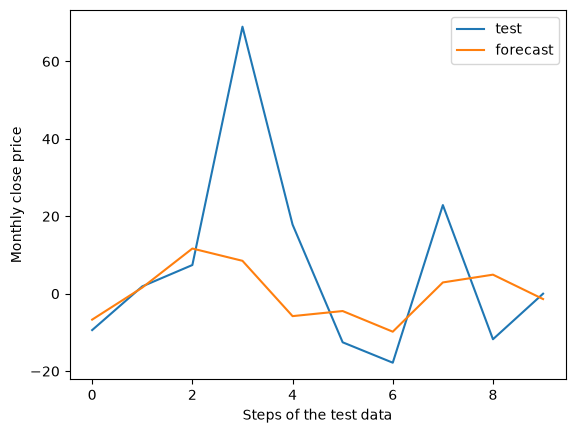

r2_score:  0.14466790933410545
rmse:  22.472754083748185
description:  count    114.000000
mean       3.935090
std       20.296620
min      -21.839080
25%       -9.040404
50%        0.000000
75%        9.772727
max       91.612903
Name: returns, dtype: float64


In [14]:
# Fitting a SARIMAX model with our best model 
# order=(2,0,1), seasonal_order=(1,2,1,10)

import random
random.seed(12345)
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import warnings

warnings.filterwarnings('ignore')

y_train=neimeth_end_month_df['returns'].dropna()[:-10]
y_test=neimeth_end_month_df['returns'].dropna()[-10:]

# scaler=StandardScaler()
# exog_train_scaled=scaler.fit_transform(X_full[:-10])
# exog_test_scaled=scaler.transform(X_full[-10:])

mod = SARIMAX(
y_train,
order=(2,0,2), 
seasonal_order=(2,0,2,12),
)

res = mod.fit(disp=False)
fcst = res.forecast(steps=10)

plt.plot(list(y_test))
plt.plot(list(fcst))
plt.xlabel('Steps of the test data')
plt.ylabel('Monthly close price')
plt.legend(['test', 'forecast'])
plt.show()
print('r2_score: ',r2_score(y_test, fcst))
print('rmse: ', np.sqrt(mean_squared_error(y_test,fcst)))
print('description: ', neimeth_end_month_df.returns.dropna().describe())

Very horrible. We will work with close_price
